# Configurable GPS Acquisition + Tracking (L1 C/A, L2C, or L5)

This notebook demonstrates a unified acquisition/tracking flow built on `Signal` from `utils.signal_interfaces`.

A signal is described by data rather than by a bespoke correlator: `utils.code_components` says how each spreading code occupies the chip clock, and a `LoopDiscriminatorPolicy` says which component drives which loop. One `utils.tracking_channel.TrackingChannel` then serves every signal. Acquisition and tracking policy are defined separately from the signal itself, in `ACQUISITION_POLICIES`/`TRACKING_POLICIES` keyed by each signal's `signal_type_id`.

| Signal | Components | How they are multiplexed | Carrier loop runs on |
|---|---|---|---|
| GPS L1 C/A | `CA` | single code, 1.023 Mcps | `CA` |
| GPS L2C | `CM`, `CL` | interleaved on alternating chip slots, 1.023 Mcps combined | `CM` |
| GPS L5 | `I`, `Q` | co-located, separated by carrier phase, 10.23 Mcps | `Q` (pilot) |

Set `SIGNAL_TYPE` in the config cell to switch (`GpsL1CA`, `GpsL2C`, or `GpsL5` -- these are classes, not enum values; constructing one for a PRN, e.g. `GpsL5(prn=1)`, builds that satellite's signal).

**L5 notes.** It chips ten times faster than the others, so the collect needs at least ~20 Msps — the next cell checks this and stops if the rate is too low. Its Neuman-Hofman overlay flips sign every 1 ms, which caps coherent integration at one code period and makes the acquisition Doppler bins 1000 Hz wide; the half-bin search is enabled to keep the seeding error inside what a 1 ms FLL can pull in. Because the overlay is still present, the pilot is not yet effectively dataless and the carrier loop remains Costas.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import utils
from utils import bpsk_acquisition, collect_metadata_utils, sample_streaming, tracking_channel
from utils.signal_interfaces import (
    GpsL1CA,
    GpsL2C,
    GpsL5,
    build_acquisition_code_params,
    build_signals,
    create_tracking_channels,
)

utils.plotting.setup_default_plotting()

In [2]:
# ----- User configuration -----
SIGNAL_ID = GpsL1CA  # GpsL1CA, GpsL2C, or GpsL5
EXPERIMENT_INDEX = 3

# Acquisition settings per signal type.
#
# `replica_duration_ms` is the coherent integration length, and it sets the
# Doppler bin width to 1 / T_coherent.  L1 C/A can integrate over several code
# periods; L2C acquires on CM alone, whose period is 20 ms.
#
# L5 is the constrained one.  Its Neuman-Hofman overlay flips sign every primary
# code period, so coherent integration is capped at 1 ms -> 1000 Hz bins -> up to
# +/-500 Hz of seeding error.  A 1 ms FLL discriminator is only unambiguous to
# +/-250 Hz, so `half_bin` is needed to halve the worst case.  Blocks are summed
# non-coherently (square law), which is why the overlay's sign flips are harmless
# across blocks.
ACQ_SETTINGS = {
    GpsL1CA: dict(replica_duration_ms=4, num_blocks=8, p_fa_total=1e-9, half_bin=False),
    GpsL2C: dict(replica_duration_ms=20, num_blocks=1, p_fa_total=1e-6, half_bin=False),
    GpsL5: dict(replica_duration_ms=1, num_blocks=20, p_fa_total=1e-6, half_bin=True),
}

# Tracking settings
BUFFER_DURATION_MS = 40
BLOCK_DURATION_MS = 1
TRACK_DURATION_MS = 10000
START_TRACKING_IN_PLL_MODE = False

# L5 chips at 10.23 Mcps, so the collect needs >= ~20 Msps to keep two samples per
# chip -- the correlator advances the chip index once per sample and would skip
# chips below that.  That is also ~5x the samples per millisecond of L1/L2, so
# these default to a shorter run.
if SIGNAL_ID is GpsL5:
    BUFFER_DURATION_MS = 50
    TRACK_DURATION_MS = 10000

print(f"Signal type: {SIGNAL_ID.signal_id}")

Signal type: GPS_L1CA


In [3]:
collects_dir = utils.environment_variables.get_collects_dir()
available_experiment_names = sorted(fp.name for fp in collects_dir.iterdir())
print("Available experiments:", ", ".join(available_experiment_names))

experiment_name = available_experiment_names[EXPERIMENT_INDEX]
experiment_dir = collects_dir / experiment_name
print(f"Selected experiment: {experiment_name}")

metadata_filepath = experiment_dir / "metadata.yml"
metadata = collect_metadata_utils.load_experiment_metadata_from_file(metadata_filepath, print_summary=True)

target_band = SIGNAL_ID.link.id.value
candidate_collect_ids = []
for cid in metadata.collect_ids:
    collect_cfg = metadata.collects[cid]
    channel_cfg = metadata.channel_configurations[collect_cfg.channel_config_id]
    if target_band in channel_cfg.band_ids:
        candidate_collect_ids.append(cid)

if len(candidate_collect_ids) == 0:
    raise RuntimeError(
        f"No collect found for target band {target_band!r}. "
        f"Bands present in this experiment: {sorted(metadata.band_ids)}"
    )

collect_id = candidate_collect_ids[0]
band_id = target_band
collect_config = metadata.collects[collect_id]
channel_config = metadata.channel_configurations[collect_config.channel_config_id]
band_config = metadata.band_configurations[band_id]

samp_rate = channel_config.samp_rate
sample_params = channel_config.sample_params
inter_freq_hz = band_config.inter_freq
collect_filepath = experiment_dir / collect_config.filename

print(f"Selected collect_id={collect_id}, band_id={band_id}")
print(f"Collect filepath: {collect_filepath}")
print(f"Sample rate: {samp_rate} Hz")

# The correlator steps the chip index once per sample, so anything below about
# two samples per chip silently skips chips rather than failing loudly.
_chip_rate = SIGNAL_ID.tracking_code_rate_chips_per_sec
_samples_per_chip = samp_rate / _chip_rate
print(f"Chip rate: {_chip_rate/1e6:.3f} Mcps  ->  {_samples_per_chip:.2f} samples/chip")
if _samples_per_chip < 2.0:
    raise RuntimeError(
        f"Sample rate {samp_rate/1e6:.1f} Msps gives only {_samples_per_chip:.2f} samples per "
        f"chip at {_chip_rate/1e6:.3f} Mcps. The correlator needs at least ~2; "
        "this collect cannot be used for this signal without resampling."
    )

Available experiments: ascension-island-2023, boulder-roof-2022, haarp-meteo, haleakala-horn-2021
Selected experiment: haleakala-horn-2021
Available bands: L1 L2 L5
Available collects:
  20210611_121000_RX3: L5
  20210611_121000_RX5: L2
  20210611_121000_RX7: L1
Selected collect_id=20210611_121000_RX7, band_id=L1
Collect filepath: /media/share/share/brianbw/data/collects/haleakala-horn-2021/20210611_121000_011501_HI_RX7.sc8
Sample rate: 5000000 Hz
Chip rate: 1.023 Mcps  ->  4.89 samples/chip


In [4]:
signals = build_signals(SIGNAL_ID)
acq_code_params = build_acquisition_code_params(SIGNAL_ID, signals)

acq_settings = ACQ_SETTINGS[SIGNAL_ID]

# Read enough samples for the full coherent x non-coherent acquisition dwell.
acq_buffer_duration_ms = acq_settings["replica_duration_ms"] * acq_settings["num_blocks"]
acq_buffer_size_samples = int(samp_rate * acq_buffer_duration_ms / 1e3)
byte_buffer = bytearray(
    sample_streaming.compute_sample_array_size_bytes(
        acq_buffer_size_samples, sample_params.bit_depth, sample_params.is_complex
    )
)
samples = np.zeros(acq_buffer_size_samples, dtype=np.complex64)
baseband_samples = np.zeros(acq_buffer_size_samples, dtype=np.complex64)

with open(collect_filepath, "rb") as f:
    f.readinto(byte_buffer)

sample_streaming.convert_to_complex64_samples(byte_buffer, samples, sample_params)
sample_streaming.mixdown_samples(
    samples,
    baseband_samples,
    samp_rate,
    initial_phase_cycles=0.0,
    freq_hz=inter_freq_hz,
)
baseband_samples -= np.mean(baseband_samples)

acq_config = bpsk_acquisition.AcquisitionConfiguration(
    replica_duration_ms=acq_settings["replica_duration_ms"],
    num_blocks=acq_settings["num_blocks"],
    sample_rate=samp_rate,
    min_search_doppler_hz=-5000,
    max_search_doppler_hz=5000,
)
num_detection_tests = acq_config.num_doppler_bins * acq_config.replica_length_samples
p_fa_bin = 1 - (1 - acq_settings["p_fa_total"]) ** (1 / num_detection_tests)

doppler_bin_hz = acq_config.fft_resolution
worst_case_error_hz = doppler_bin_hz / (4 if acq_settings["half_bin"] else 2)
print(f"Doppler bin width: {doppler_bin_hz:.1f} Hz "
      f"(half-bin search {'on' if acq_settings['half_bin'] else 'off'}) "
      f"-> worst-case seeding error {worst_case_error_hz:.1f} Hz")

acq_results = bpsk_acquisition.run_acquisition(
    sample_block=baseband_samples,
    sample_block_uptime_epoch_ms=0.0,
    acq_config=acq_config,
    code_parameters=acq_code_params,
    prob_false_alaram=p_fa_bin,
    print_progress=True,
    noise_var_method="abscorrvar",
    half_bin_doppler_search=acq_settings["half_bin"],
)

acquired_signal_ids = sorted([
    sid for sid, result in acq_results.items() if result.signal_detected
])
print(f"Acquired signals ({SIGNAL_ID.signal_id}): {', '.join(acquired_signal_ids)}")

Doppler bin width: 250.0 Hz (half-bin search off) -> worst-case seeding error 125.0 Hz
Acquiring signal G01...74.116
Acquiring signal G02...1041.424*
Acquiring signal G03...63.614
Acquiring signal G04...64.667
Acquiring signal G05...103.188
Acquiring signal G06...1126.057*
Acquiring signal G07...83.809
Acquiring signal G08...71.529
Acquiring signal G09...195.644*
Acquiring signal G10...76.229
Acquiring signal G11...71.833
Acquiring signal G12...66.232
Acquiring signal G13...122.881*
Acquiring signal G14...73.721
Acquiring signal G15...61.913
Acquiring signal G16...68.562
Acquiring signal G17...833.586*
Acquiring signal G18...60.716
Acquiring signal G19...1428.237*
Acquiring signal G20...72.788
Acquiring signal G21...70.631
Acquiring signal G22...69.630
Acquiring signal G23...73.338
Acquiring signal G24...66.523
Acquiring signal G25...73.813
Acquiring signal G26...68.200
Acquiring signal G27...61.048
Acquiring signal G28...258.674*
Acquiring signal G29...66.823
Acquiring signal G30...73

In [ ]:
if len(acquired_signal_ids) == 0:
    raise RuntimeError("No signals acquired; cannot start tracking.")

buffer_size_samples = int(samp_rate * BUFFER_DURATION_MS / 1e3)
num_buffers_to_process = TRACK_DURATION_MS // BUFFER_DURATION_MS
output_capacity = TRACK_DURATION_MS // BLOCK_DURATION_MS

tracking_loop_params = tracking_channel.TrackingLoopParameters(
    DLL_bandwidth_hz=2.0,
    PLL_bandwidth_hz=20.0,
    FLL_bandwidth_hz=50.0,
    nominal_update_period_ms=BLOCK_DURATION_MS,
    corr_period_ms=BLOCK_DURATION_MS,
    EPL_chip_spacing=0.5,
    prompt_corr_circ_length_threshold=0.9,
)

tracking_channels = create_tracking_channels(
    SIGNAL_ID,
    signals=signals,
    acquisition_results=acq_results,
    tracking_signal_ids=acquired_signal_ids,
    loop_params=tracking_loop_params,
    output_capacity=output_capacity,
    start_mode_pll=START_TRACKING_IN_PLL_MODE,
)

with sample_streaming.FileSampleStream(
    collect_filepath,
    sample_params,
    buffer_size_samples,
) as sample_stream:
    sample_buffer_generator = sample_stream.sample_buffer_generator()
    for i_buffer, buffer_samples in enumerate(sample_buffer_generator):
        if i_buffer >= num_buffers_to_process:
            break
        # Print progress
        print(f"\r {i_buffer:04} / {num_buffers_to_process:04}", end="")
        uptime_ms = i_buffer * BUFFER_DURATION_MS
        mixdown_phase_cycles = inter_freq_hz * (uptime_ms * 1e-3)
        sample_streaming.mixdown_samples(
            buffer_samples,
            buffer_samples,
            samp_rate,
            initial_phase_cycles=mixdown_phase_cycles,
            freq_hz=inter_freq_hz,
        )

        sample_buffer = sample_streaming.SampleBuffer(
            samples=buffer_samples,
            start_uptime_ms=uptime_ms,
            samp_rate=samp_rate,
        )
        for adapter in tracking_channels.values():
            adapter.process_sample_buffer(sample_buffer)

print("Tracking complete")

 0080 / 0250

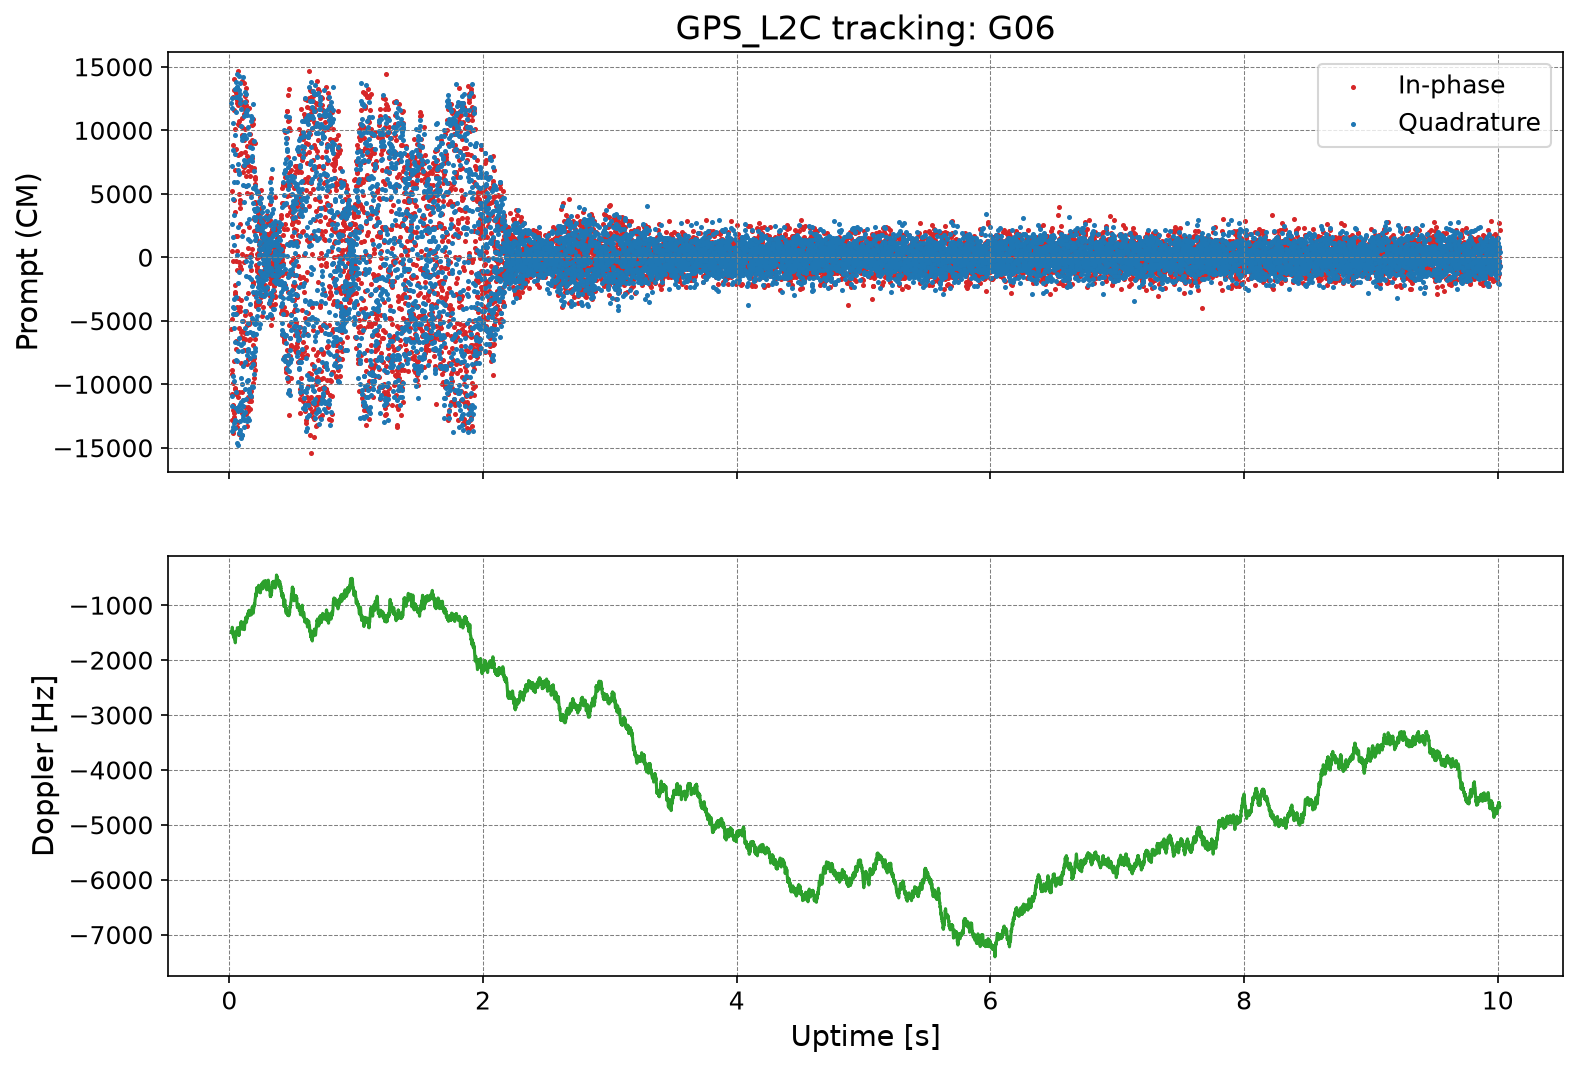

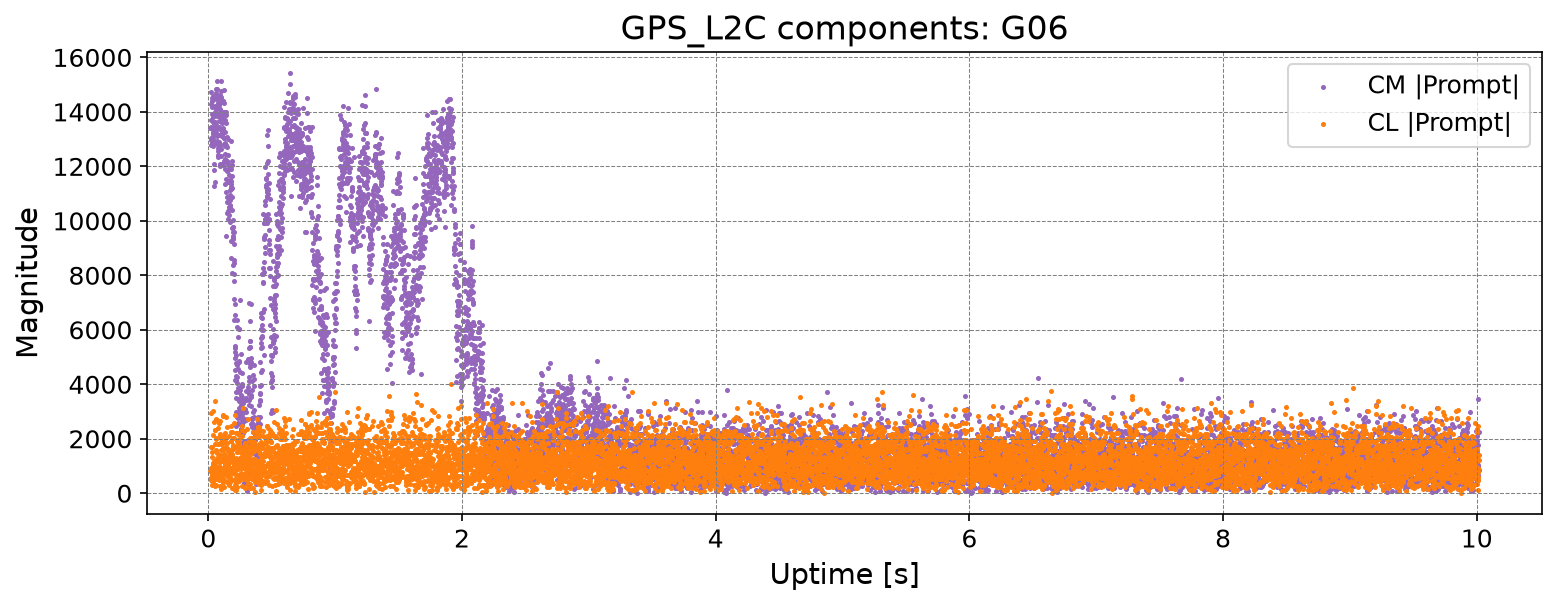

In [ ]:
plot_sig_id = acquired_signal_ids[0]
adapter = tracking_channels[plot_sig_id]
outputs = adapter.outputs
component_names = adapter.signal.component_names

# The component the carrier loop runs on: CA for L1 C/A, CM for L2C, the Q pilot
# for L5.  That is the one whose I/Q constellation should be collapsed onto the
# real axis by the PLL.  Read off the channel's own (live) policy rather than the
# signal type's default, since overlay sync can switch it mid-track (see L5).
carrier_index = adapter.channel.policy.carrier_component
carrier_prompt = adapter.get_prompt_component(component=carrier_index)

# `outputs` pre-allocates output_capacity epochs and only fills the first
# `output_index` of them; slice to that range so the unwritten (zero) tail
# doesn't get plotted -- e.g. as a spurious line back to (0, 0) below.
plot_time = outputs.uptime_epoch_ms[outputs.valid] * 1e-3
doppler_freq_hz = outputs.doppler_freq_hz[outputs.valid]

fig = plt.figure(figsize=(12, 8), dpi=150)
axes = fig.subplots(2, 1, sharex=True)

axes[0].scatter(plot_time, carrier_prompt.real, s=2, color="tab:red", label="In-phase")
axes[0].scatter(plot_time, carrier_prompt.imag, s=2, color="tab:blue", label="Quadrature")
axes[0].set_ylabel(f"Prompt ({component_names[carrier_index]})")
axes[0].set_title(f"{SIGNAL_ID.signal_id} tracking: {plot_sig_id}")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(plot_time, doppler_freq_hz, lw=1.5, color="tab:green")
axes[1].set_ylabel("Doppler [Hz]")
axes[1].set_xlabel("Uptime [s]")
axes[1].grid(True)

# Multi-component signals: compare the components' prompt magnitudes.
#   L2C  - CM and CL each occupy half the chip slots, so both sit near half the
#          magnitude a single full-rate code would reach.
#   L5   - I and Q are equal power and should track each other closely.
if len(component_names) > 1:
    fig2 = plt.figure(figsize=(12, 4), dpi=150)
    ax2 = fig2.add_subplot(1, 1, 1)
    for index, (name, color) in enumerate(zip(component_names, ("tab:purple", "tab:orange"))):
        prompt = adapter.get_prompt_component(component=index)
        ax2.scatter(plot_time, np.abs(prompt), s=2, label=f"{name} |Prompt|", color=color)
    ax2.set_title(f"{SIGNAL_ID.signal_id} components: {plot_sig_id}")
    ax2.set_ylabel("Magnitude")
    ax2.set_xlabel("Uptime [s]")
    ax2.grid(True)
    ax2.legend()

plt.show()